In [1]:
!pip install matplotlib seaborn scikit-learn pandas --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 1.2 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 1.1 MB/s  0:00:08 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 1.2 MB/s  0:00:10m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 1.1 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 1.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 1.2 MB/s  0:00:14m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 1.1 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 1.2 MB/s  0:00:30m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15/15 [seaborn]4/15 [seaborn]ib]n]


In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def get_na(data):
    for column in data.columns:
        print("column: ", column, "; total=", data[column].isna().sum())

In [90]:
def check_proportion(data):

    grouped_data = data.groupby("sex")["alive"].value_counts()
    total = grouped_data.values.sum()
    sex = [ di[0] for di in grouped_data.index ]
    alive = [ di[1] for di in grouped_data.index ]
    values = grouped_data.values
    
    new_data = pd.DataFrame({"sex":sex, "alive":alive, "values":values})
    ax = sns.barplot(data=new_data, x="alive", y="values", hue="sex")


    for p in ax.patches:
        height = p.get_height()
        if(height <= 0):
            continue
        label = f"{(height/total)*100:.2f}%"
        
        ax.text(p.get_x() + p.get_width() / 2, height, label, ha='center', va='bottom', fontsize=12)

    plt.show()

In [5]:
data = sns.load_dataset("titanic")

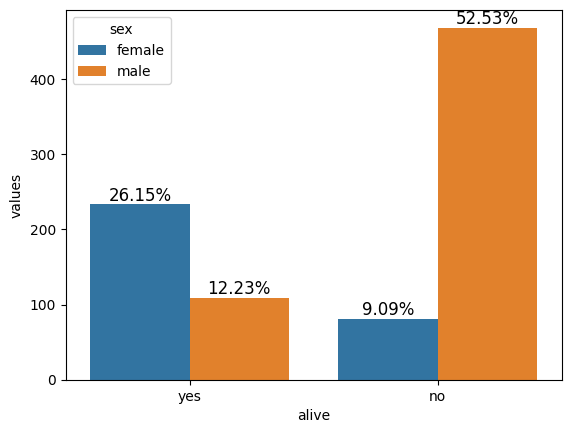

In [91]:
check_proportion(data)


In [92]:

data.deck = data.deck.cat.add_categories("H").fillna("H")
data.embark_town = data.embark_town.fillna("O")
data.embarked = data.embark_town.fillna("N")

data = data.dropna()
get_na(data)

data.shape

column:  survived ; total= 0
column:  pclass ; total= 0
column:  sex ; total= 0
column:  age ; total= 0
column:  sibsp ; total= 0
column:  parch ; total= 0
column:  fare ; total= 0
column:  embarked ; total= 0
column:  class ; total= 0
column:  who ; total= 0
column:  adult_male ; total= 0
column:  deck ; total= 0
column:  embark_town ; total= 0
column:  alive ; total= 0
column:  alone ; total= 0


(714, 15)

In [93]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,Southampton,Third,man,True,H,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,Cherbourg,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,Southampton,Third,woman,False,H,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,Southampton,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,Southampton,Third,man,True,H,Southampton,no,True


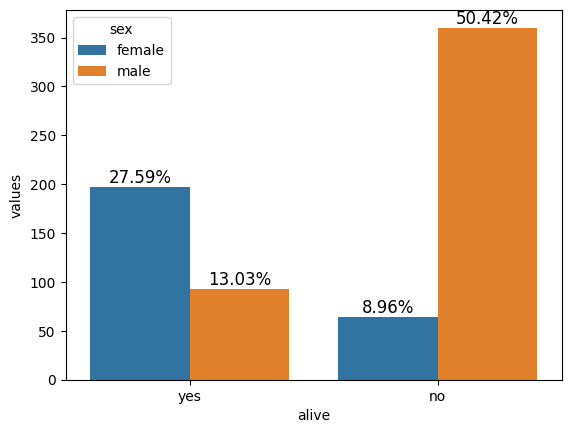

In [94]:
check_proportion(data)


In [95]:
data.corr(numeric_only=True).style.background_gradient()

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.359653,-0.077221,-0.017358,0.093317,0.268189,-0.552936,-0.196140
pclass,-0.359653,1.000000,-0.369226,0.067247,0.025683,-0.554182,0.099021,0.146320
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,0.280328,0.198270
sibsp,-0.017358,0.067247,-0.308247,1.000000,0.383820,0.138329,-0.310463,-0.629818
parch,0.093317,0.025683,-0.189119,0.383820,1.000000,0.205119,-0.363079,-0.577524
fare,0.268189,-0.554182,0.096067,0.138329,0.205119,1.000000,-0.179740,-0.260136
adult_male,-0.552936,0.099021,0.280328,-0.310463,-0.363079,-0.179740,1.000000,0.396632
alone,-0.196140,0.146320,0.198270,-0.629818,-0.577524,-0.260136,0.396632,1.000000


# Questões
1. pessoas sozinhas tinham maior possibilidade de sobreviver ?
2. pais tinham mais chances de morrer?
3. pessoas que pagaram mais eram mais propensas a sobreviverem?
4. a idade influencia na chance de sobreviver?
5. familias grandes sobreviveram mais?
6. `adult_male` ou `alone` tem maior relação com a coluna target (`survived`)?
7. mais velhos que tinham parentes morreram mais?

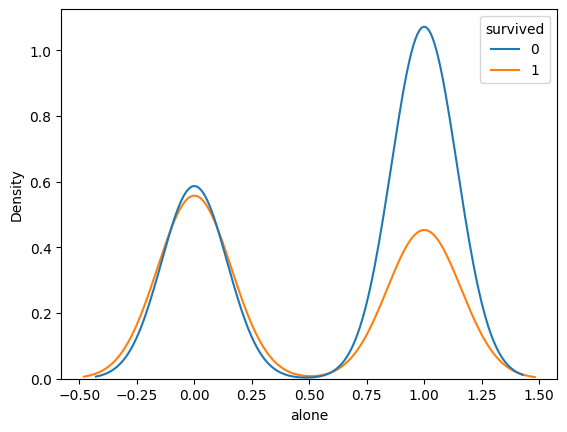

In [120]:
sns.kdeplot(data=data, x="alone", hue="survived")
plt.show()

# questão 1: não

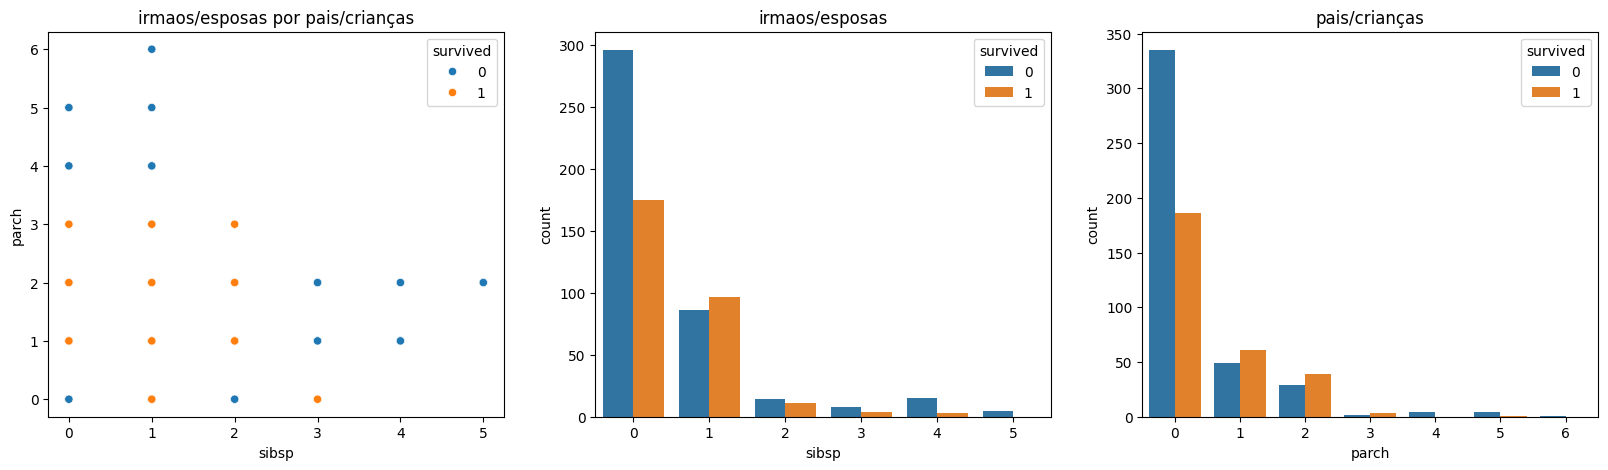

In [136]:
fig,ax = plt.subplots(1,3,figsize=(20,5))

sns.scatterplot(data=data, x="sibsp", y="parch", hue="survived", ax=ax[0])
sns.countplot(data=data, x="sibsp", hue="survived", ax=ax[1])
sns.countplot(data=data, x="parch", hue="survived", ax=ax[2])

ax[0].set_title("irmaos/esposas por pais/crianças")
ax[1].set_title("irmaos/esposas")
ax[2].set_title("pais/crianças")
plt.show()
# Questão 2: Não

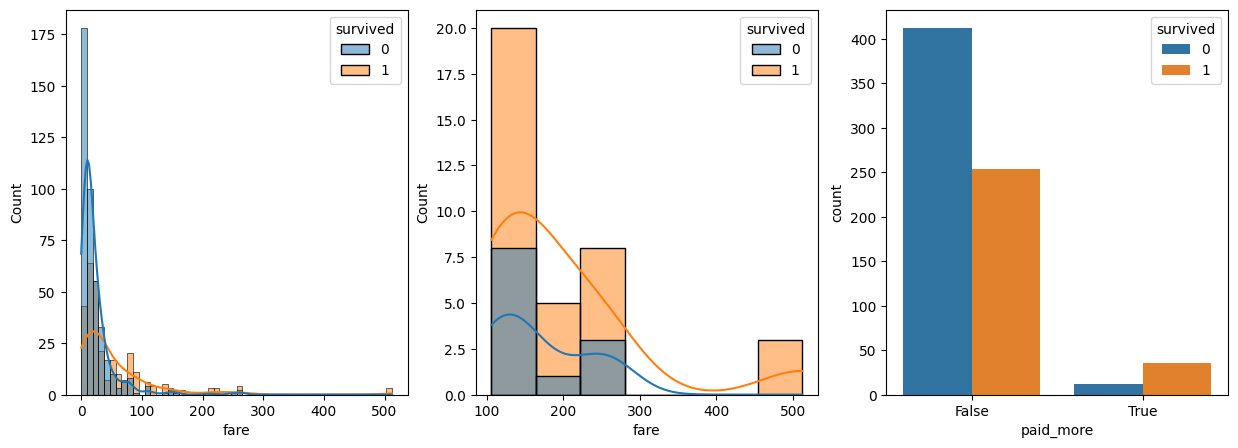

In [164]:
fig,ax = plt.subplots(1,3,figsize=(15,5))

subset_fare = data.loc[data.fare > 100]

subset_paid_less_or_not = data
subset_paid_less_or_not.loc[subset_paid_less_or_not.fare < 100, "paid_more"] = False
subset_paid_less_or_not.loc[subset_paid_less_or_not.fare >= 100, "paid_more"] = True

sns.histplot(data=data, x="fare", hue="survived",ax=ax[0], kde=True)
sns.histplot(data=subset_fare, x="fare", hue="survived",ax=ax[1], kde=True)
sns.countplot(data=subset_paid_less_or_not, x="paid_more", hue="survived",ax=ax[2])

plt.show()
# Questao 3 : Nao

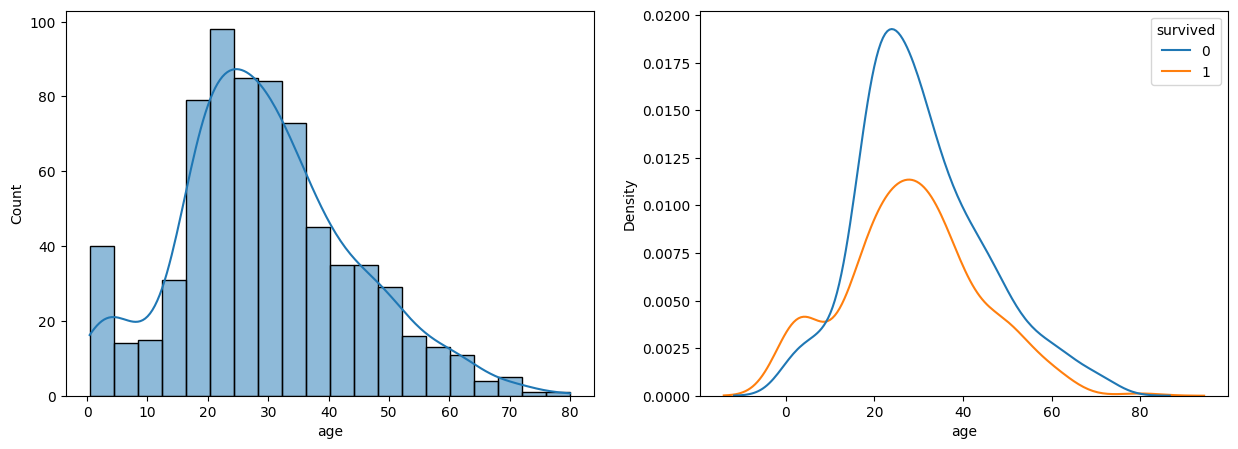

In [144]:
fig,ax = plt.subplots(1,2, figsize=(15,5))

sns.histplot(data=data, x="age", ax=ax[0], kde=True)
sns.kdeplot(data=data, x="age", hue="survived", ax=ax[1])
plt.show()

# Questão 5: Não necessáriamente, tem muitos dados de uma mesma idade e poucos de outras